# 04 — Training

Train the transformer to predict the next token in Gambler's Ruin sequences
via cross-entropy loss.  Save the best checkpoint to disk.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split
from tqdm.auto import tqdm

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

## Configuration

In [2]:
# -- Papermill parameters -----------------------------------------------------
DATA_DIR = "projects/markov-transformer/experiments/markov-chain-learning/data"
EMBEDDING_VARIANT = "full"  # full | no_token | no_pos | no_embeddings

# Model
VOCAB_SIZE = 3
D_MODEL = 32
NHEAD = 4
NUM_ATTENTION_LAYERS = 2
DIM_FEEDFORWARD = 64
MAX_LEN = 64

# Training
BATCH_SIZE = 256
EPOCHS = 50
LR = 3e-3
VAL_SPLIT = 0.1
SEED = 42

In [3]:
# Parameters
DATA_DIR = "/Users/ashrafahmed/workspace/slt-deep/projects/markov-transformer/experiments/markov-chain-learning/data/single"
EMBEDDING_VARIANT = "full"
EPOCHS = 5

In [4]:
# -- Post-papermill coercions -------------------------------------------------
DATA_DIR = Path(DATA_DIR)
EPOCHS = int(EPOCHS)
BATCH_SIZE = int(BATCH_SIZE)
SEED = int(SEED)
NHEAD = int(NHEAD)
NUM_ATTENTION_LAYERS = int(NUM_ATTENTION_LAYERS)
D_MODEL = int(D_MODEL)
DIM_FEEDFORWARD = int(DIM_FEEDFORWARD)
MAX_LEN = int(MAX_LEN)
VOCAB_SIZE = int(VOCAB_SIZE)

torch.manual_seed(SEED)
print("Data dir:", DATA_DIR.resolve())
print(f"Embedding variant: {EMBEDDING_VARIANT}")

VARIANT_FLAGS = {
    "full": dict(use_token_embedding=True, use_pos_embedding=True),
    "no_token": dict(use_token_embedding=False, use_pos_embedding=True),
    "no_pos": dict(use_token_embedding=True, use_pos_embedding=False),
    "no_embeddings": dict(use_token_embedding=False, use_pos_embedding=False),
}
if EMBEDDING_VARIANT not in VARIANT_FLAGS:
    raise ValueError(f"Unknown EMBEDDING_VARIANT: {EMBEDDING_VARIANT!r}")

Data dir: /Users/ashrafahmed/workspace/slt-deep/projects/markov-transformer/experiments/markov-chain-learning/data/single
Embedding variant: full


## Model (copy from 03_model.ipynb for self-containment)

In [5]:
class AttentionOnlyBlock(nn.Module):
    """Causal self-attention block without a feedforward sublayer."""

    def __init__(self, d_model: int, nhead: int):
        super().__init__()
        self.norm = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=nhead,
            dropout=0.0,
            batch_first=True,
        )

    def forward(self, x: torch.Tensor, attn_mask: torch.Tensor) -> torch.Tensor:
        h = self.norm(x)
        out, _ = self.attn(h, h, h, attn_mask=attn_mask, need_weights=False)
        return x + out


class MarkovTransformer(nn.Module):
    """Minimal transformer: N attention-only blocks + 1 shared MLP head."""

    def __init__(
        self,
        vocab_size: int = 3,
        d_model: int = 32,
        nhead: int = 4,
        num_attention_layers: int = 2,
        dim_feedforward: int = 64,
        max_len: int = 64,
        use_token_embedding: bool = True,
        use_pos_embedding: bool = True,
    ):
        super().__init__()
        self.vocab_size = vocab_size
        self.d_model = d_model
        self.use_token_embedding = use_token_embedding
        self.use_pos_embedding = use_pos_embedding

        if use_token_embedding:
            self.token_embedding = nn.Embedding(vocab_size, d_model)
            self.token_projection = None
        else:
            self.token_embedding = None
            self.token_projection = nn.Linear(vocab_size, d_model, bias=False)

        if use_pos_embedding:
            self.pos_embedding = nn.Embedding(max_len, d_model)
        else:
            self.pos_embedding = None

        self.attention_blocks = nn.ModuleList(
            [
                AttentionOnlyBlock(d_model=d_model, nhead=nhead)
                for _ in range(num_attention_layers)
            ]
        )
        self.mlp_norm = nn.LayerNorm(d_model)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.GELU(),
            nn.Linear(dim_feedforward, d_model),
        )
        self.head = nn.Linear(d_model, vocab_size, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        _, L = x.shape
        if self.use_token_embedding:
            h = self.token_embedding(x)
        else:
            x_one_hot = F.one_hot(x, num_classes=self.vocab_size).float()
            h = self.token_projection(x_one_hot)
        if self.use_pos_embedding:
            positions = torch.arange(L, device=x.device)
            h = h + self.pos_embedding(positions)
        causal_mask = torch.triu(
            torch.full((L, L), float("-inf"), device=x.device), diagonal=1
        )
        for block in self.attention_blocks:
            h = block(h, attn_mask=causal_mask)
        h = h + self.mlp(self.mlp_norm(h))
        return self.head(h)

## Load data

In [6]:
class MarkovSequenceDataset(Dataset):
    def __init__(self, sequences: torch.Tensor):
        self.data = sequences

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


data = torch.load(DATA_DIR / "sequences.pt", weights_only=True)
sequences = data["sequences"]
Ts = data["Ts"]
pis = data["pis"]
data_cfg = data.get("config", {})
PAD_ID = int(data_cfg.get("pad_id", -1))
DGP_REGIME = data_cfg.get("dgp_regime", "unknown")
VOCAB_SIZE = int(data_cfg.get("n_states", VOCAB_SIZE))

print(f"DGP regime  : {DGP_REGIME}")
print(f"Loaded {len(sequences)} sequences, shape {tuple(sequences.shape)}")
print(f"PAD_ID={PAD_ID},  Ts shape: {tuple(Ts.shape)},  VOCAB_SIZE={VOCAB_SIZE}")

full_ds = MarkovSequenceDataset(sequences)
n_val = int(len(full_ds) * VAL_SPLIT)
n_train = len(full_ds) - n_val
train_ds, val_ds = random_split(
    full_ds,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED),
)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
print(f"Train: {n_train}   Val: {n_val}")

DGP regime  : single
Loaded 10000 sequences, shape (10000, 32)
PAD_ID=-1,  Ts shape: (1, 3, 3),  VOCAB_SIZE=3
Train: 9000   Val: 1000


## Training loop

In [7]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print("Device:", device)

model = MarkovTransformer(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    nhead=NHEAD,
    num_attention_layers=NUM_ATTENTION_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    max_len=MAX_LEN,
    **VARIANT_FLAGS[EMBEDDING_VARIANT],
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)


def run_epoch(loader, training: bool):
    model.train(training)
    total_loss, n_tokens = 0.0, 0
    with torch.set_grad_enabled(training):
        for batch in loader:
            batch = batch.to(device)
            x_in = batch[:, :-1]
            x_tgt = batch[:, 1:]
            logits = model(x_in)
            _, _, V = logits.shape
            loss = criterion(logits.reshape(-1, V), x_tgt.reshape(-1))

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            valid_tokens = (x_tgt != PAD_ID).sum().item()
            total_loss += loss.item() * valid_tokens
            n_tokens += valid_tokens

    return total_loss / max(n_tokens, 1)


train_losses, val_losses, grad_norms = [], [], []
best_val_loss = float("inf")
ckpt_name = f"checkpoint_{EMBEDDING_VARIANT}.pt"

for epoch in tqdm(range(1, EPOCHS + 1), desc="Training"):
    tr_loss = run_epoch(train_loader, training=True)
    val_loss = run_epoch(val_loader, training=False)
    train_losses.append(tr_loss)
    val_losses.append(val_loss)

    gnorm = (
        sum(p.grad.norm().item() ** 2 for p in model.parameters() if p.grad is not None)
        ** 0.5
    )
    grad_norms.append(gnorm)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(
            {
                "model_state": model.state_dict(),
                "config": dict(
                    vocab_size=VOCAB_SIZE,
                    d_model=D_MODEL,
                    nhead=NHEAD,
                    num_attention_layers=NUM_ATTENTION_LAYERS,
                    dim_feedforward=DIM_FEEDFORWARD,
                    max_len=MAX_LEN,
                    use_token_embedding=VARIANT_FLAGS[EMBEDDING_VARIANT][
                        "use_token_embedding"
                    ],
                    use_pos_embedding=VARIANT_FLAGS[EMBEDDING_VARIANT][
                        "use_pos_embedding"
                    ],
                ),
                "best_val_loss": best_val_loss,
                "epoch": epoch,
                "training": {
                    "embedding_variant": EMBEDDING_VARIANT,
                    "dgp_regime": DGP_REGIME,
                },
            },
            DATA_DIR / ckpt_name,
        )

print(f"\nBest val loss : {best_val_loss:.4f}  (checkpoint: {ckpt_name})")
print(f"Uniform entropy: {torch.log(torch.tensor(float(VOCAB_SIZE))):.4f}")

Device: mps


Training:   0%|          | 0/5 [00:00<?, ?it/s]


Best val loss : 0.7716  (checkpoint: checkpoint_full.pt)
Uniform entropy: 1.0986


## Loss curve

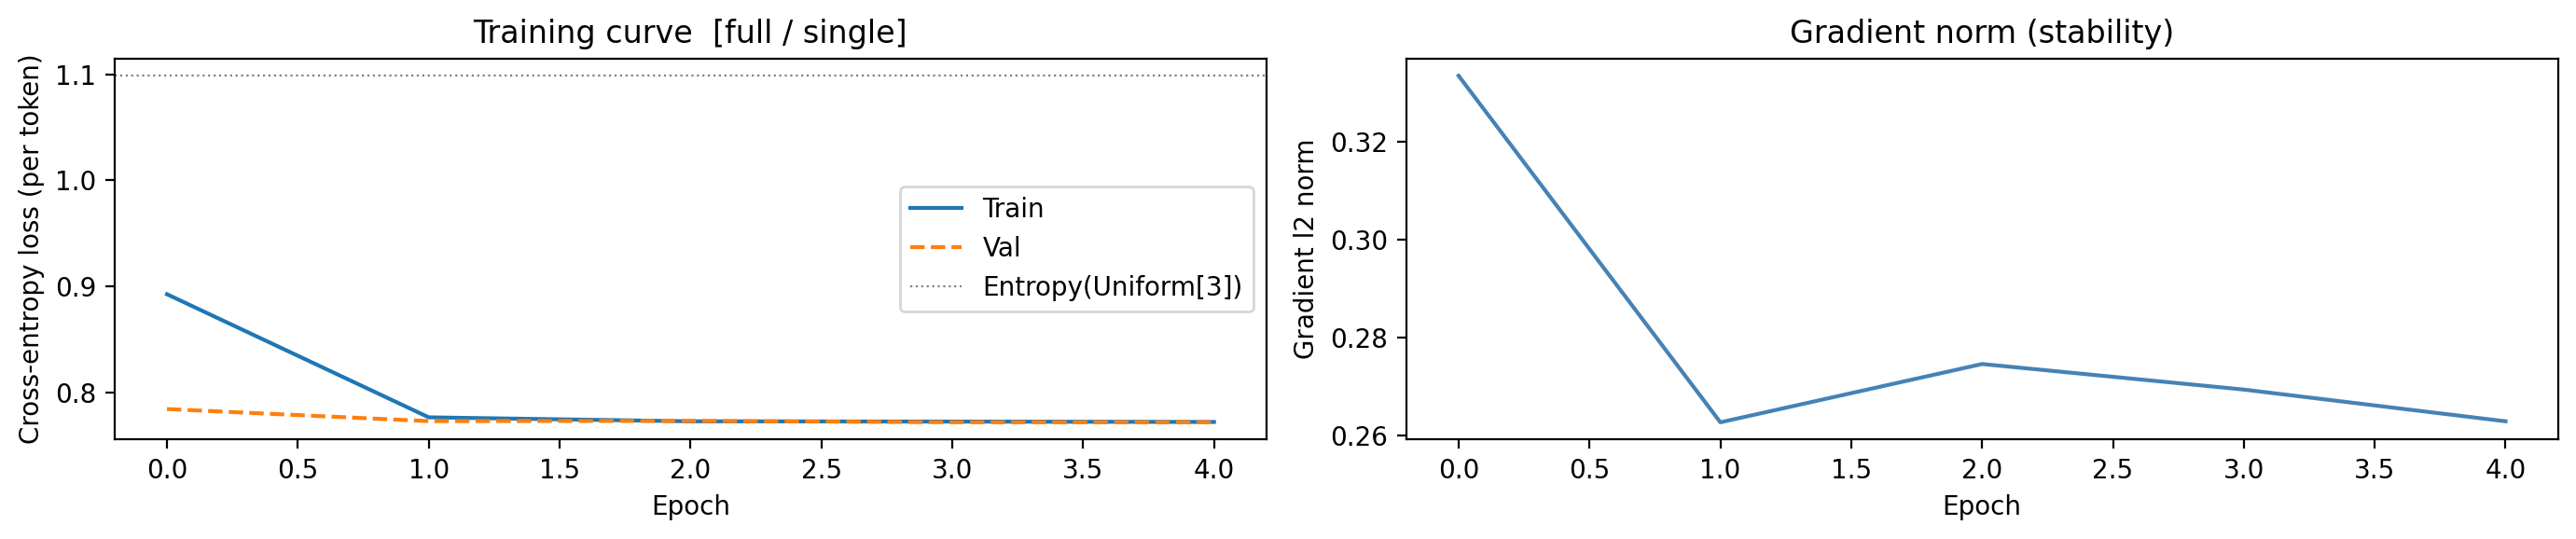

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 3))

axes[0].plot(train_losses, label="Train")
axes[0].plot(val_losses, label="Val", linestyle="--")
axes[0].axhline(
    torch.log(torch.tensor(float(VOCAB_SIZE))).item(),
    color="gray",
    linestyle=":",
    linewidth=0.8,
    label=f"Entropy(Uniform[{VOCAB_SIZE}])",
)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy loss (per token)")
axes[0].set_title(f"Training curve  [{EMBEDDING_VARIANT} / {DGP_REGIME}]")
axes[0].legend()

axes[1].plot(grad_norms, color="steelblue")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Gradient l2 norm")
axes[1].set_title("Gradient norm (stability)")

plt.tight_layout()
plt.show()